# Household Energy Consumption Forecasting

## 1. Project Objective

The objective of this project is to develop a machine learning-based
time-series forecasting system that predicts household appliance energy
consumption for the next 24 hours.

The original dataset contains energy and environmental measurements
recorded at 10-minute intervals.

For the forecasting system, the original observations will later be
aggregated to hourly resolution.

The final system will:

- Forecast the next 24 hours of appliance energy consumption.
- Compare multiple forecasting and machine learning approaches.
- Identify periods of high predicted energy consumption.
- Provide simple recommendations based on the forecast.
- Present the results through an interactive Streamlit dashboard.

At this stage, the focus is only on understanding the raw dataset.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

pd.set_option("display.max_columns", None)
pd.set_option("display.max_rows", 100)

Matplotlib is building the font cache; this may take a moment.


In [2]:
DATA_PATH = "D:/Energy_Forecasting/data/raw/energydata_complete.csv"

df = pd.read_csv(DATA_PATH)

In [3]:
df.head()

,date,Appliances,lights,T1,RH_1,T2,RH_2,T3,RH_3,T4,RH_4,T5,RH_5,T6,RH_6,T7,RH_7,T8,RH_8,T9,RH_9,T_out,Press_mm_hg,RH_out,Windspeed,Visibility,Tdewpoint,rv1,rv2
0,2016-01-11 17:00:00,60,30,19.89,47.596667,19.2,44.790000,19.79,44.730000,19.000000,45.566667,17.166667,55.20,7.026667,84.256667,17.200000,41.626667,18.2,48.900000,17.033333,45.53,6.600000,733.5,92.0,7.000000,63.000000,5.3,13.275433,13.275433
1,2016-01-11 17:10:00,60,30,19.89,46.693333,19.2,44.722500,19.79,44.790000,19.000000,45.992500,17.166667,55.20,6.833333,84.063333,17.200000,41.560000,18.2,48.863333,17.066667,45.56,6.483333,733.6,92.0,6.666667,59.166667,5.2,18.606195,18.606195
2,2016-01-11 17:20:00,50,30,19.89,46.300000,19.2,44.626667,19.79,44.933333,18.926667,45.890000,17.166667,55.09,6.560000,83.156667,17.200000,41.433333,18.2,48.730000,17.000000,45.50,6.366667,733.7,92.0,6.333333,55.333333,5.1,28.642668,28.642668
3,2016-01-11 17:30:00,50,40,19.89,46.066667,19.2,44.590000,19.79,45.000000,18.890000,45.723333,17.166667,55.09,6.433333,83.423333,17.133333,41.290000,18.1,48.590000,17.000000,45.40,6.250000,733.8,92.0,6.000000,51.500000,5.0,45.410389,45.410389
4,2016-01-11 17:40:00,60,40,19.89,46.333333,19.2,44.530000,19.79,45.000000,18.890000,45.530000,17.200000,55.09,6.366667,84.893333,17.200000,41.230000,18.1,48.590000,17.000000,45.40,6.133333,733.9,92.0,5.666667,47.666667,4.9,10.084097,10.084097


In [6]:
print("Number of rows:", df.shape[0])
print("Number of columns:", df.shape[1])
df.shape

Number of rows: 19735
Number of columns: 29


(19735, 29)

In [10]:
df.columns.tolist()

['date',
 'Appliances',
 'lights',
 'T1',
 'RH_1',
 'T2',
 'RH_2',
 'T3',
 'RH_3',
 'T4',
 'RH_4',
 'T5',
 'RH_5',
 'T6',
 'RH_6',
 'T7',
 'RH_7',
 'T8',
 'RH_8',
 'T9',
 'RH_9',
 'T_out',
 'Press_mm_hg',
 'RH_out',
 'Windspeed',
 'Visibility',
 'Tdewpoint',
 'rv1',
 'rv2']

In [11]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 19735 entries, 0 to 19734
Data columns (total 29 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   date         19735 non-null  str    
 1   Appliances   19735 non-null  int64  
 2   lights       19735 non-null  int64  
 3   T1           19735 non-null  float64
 4   RH_1         19735 non-null  float64
 5   T2           19735 non-null  float64
 6   RH_2         19735 non-null  float64
 7   T3           19735 non-null  float64
 8   RH_3         19735 non-null  float64
 9   T4           19735 non-null  float64
 10  RH_4         19735 non-null  float64
 11  T5           19735 non-null  float64
 12  RH_5         19735 non-null  float64
 13  T6           19735 non-null  float64
 14  RH_6         19735 non-null  float64
 15  T7           19735 non-null  float64
 16  RH_7         19735 non-null  float64
 17  T8           19735 non-null  float64
 18  RH_8         19735 non-null  float64
 19  T9           19

In [12]:
date_check = pd.to_datetime(df["date"])

print("First timestamp:", date_check.min())
print("Last timestamp:", date_check.max())

First timestamp: 2016-01-11 17:00:00
Last timestamp: 2016-05-27 18:00:00


In [13]:
time_diff = date_check.sort_values().diff()
time_diff.value_counts().head(10)

date
0 days 00:10:00    19734
Name: count, dtype: int64

In [17]:
missing_values = df.isnull().sum()
missing_values[missing_values > 0]

Series([], dtype: int64)

In [18]:
print("Total missing values:", df.isnull().sum().sum())

Total missing values: 0


In [19]:
print("Duplicate timestamps:", df["date"].duplicated().sum())

Duplicate timestamps: 0


In [20]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
Appliances,19735.0,97.694958,102.524891,10.000000,50.000000,60.000000,100.000000,1080.000000
lights,19735.0,3.801875,7.935988,0.000000,0.000000,0.000000,0.000000,70.000000
T1,19735.0,21.686571,1.606066,16.790000,20.760000,21.600000,22.600000,26.260000
RH_1,19735.0,40.259739,3.979299,27.023333,37.333333,39.656667,43.066667,63.360000
T2,19735.0,20.341219,2.192974,16.100000,18.790000,20.000000,21.500000,29.856667
RH_2,19735.0,40.420420,4.069813,20.463333,37.900000,40.500000,43.260000,56.026667
T3,19735.0,22.267611,2.006111,17.200000,20.790000,22.100000,23.290000,29.236000
RH_3,19735.0,39.242500,3.254576,28.766667,36.900000,38.530000,41.760000,50.163333
T4,19735.0,20.855335,2.042884,15.100000,19.530000,20.666667,22.100000,26.200000
RH_4,19735.0,39.026904,4.341321,27.660000,35.530000,38.400000,42.156667,51.090000


In [21]:
df["Appliances"].describe()

count    19735.000000
mean        97.694958
std        102.524891
min         10.000000
25%         50.000000
50%         60.000000
75%        100.000000
max       1080.000000
Name: Appliances, dtype: float64

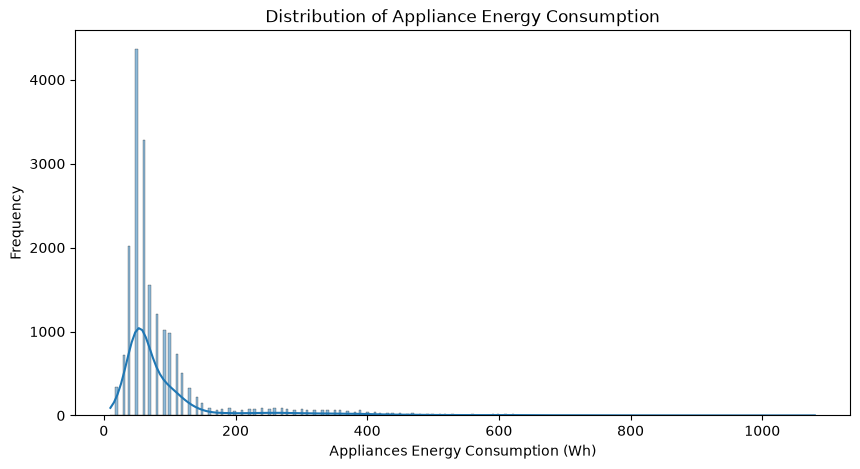

In [22]:
plt.figure(figsize=(10, 5))

sns.histplot(df["Appliances"], kde=True)

plt.title("Distribution of Appliance Energy Consumption")
plt.xlabel("Appliances Energy Consumption (Wh)")
plt.ylabel("Frequency")

plt.show()

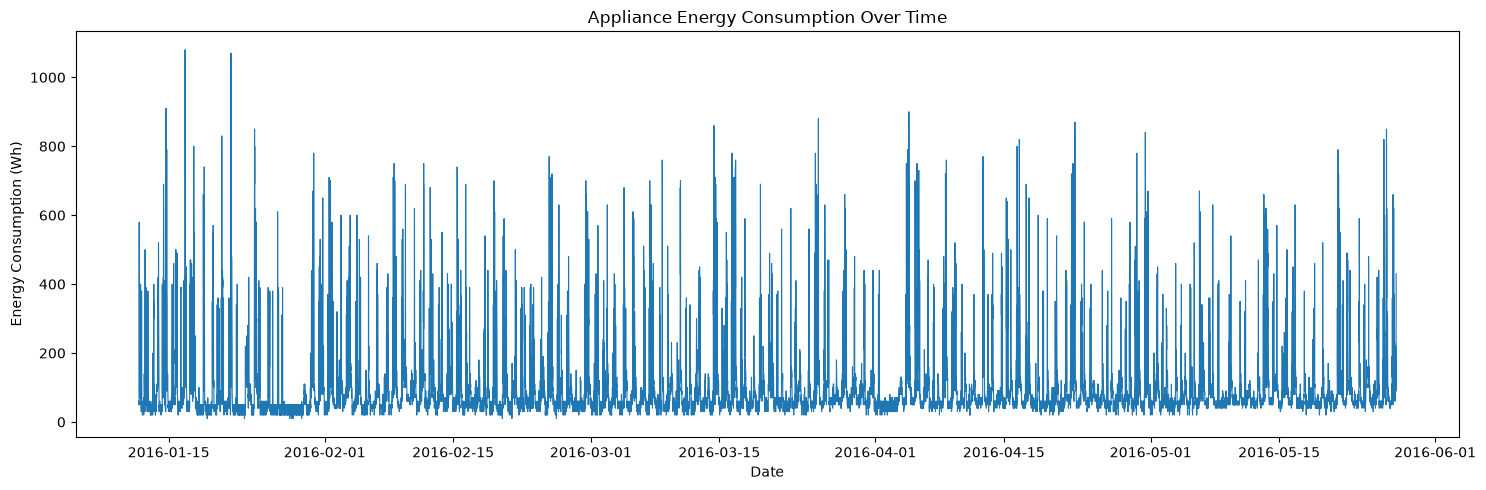

In [ ]:
#Inspect the target over time
plt.figure(figsize=(15, 5))

plt.plot(
    date_check,
    df["Appliances"],
    linewidth=0.8
)

plt.title("Appliance Energy Consumption Over Time")
plt.xlabel("Date")
plt.ylabel("Energy Consumption (Wh)")

plt.tight_layout()
plt.show()

In [ ]:
# copy for time-series validation
df_check = df.copy()

# Convert date to datetime
df_check["date"] = pd.to_datetime(df_check["date"])

# Set date as index
df_check = df_check.set_index("date")

# Count observations per hour
observations_per_hour = df_check.resample("h").size()

print(observations_per_hour.value_counts().sort_index())

1       1
6    3289
Name: count, dtype: int64


In [25]:
print("Hours with fewer than 6 observations:",(observations_per_hour < 6).sum())
print("Hours with more than 6 observations:",(observations_per_hour > 6).sum())

Hours with fewer than 6 observations: 1
Hours with more than 6 observations: 0


## Hourly Data Preparation

The original dataset contains observations at 10-minute intervals.

The dataset contains 3,289 complete hourly periods and one incomplete
hour containing only one observation. The incomplete final hour will
be excluded before hourly aggregation.

Energy variables (`Appliances` and `lights`) will be aggregated using
sum, while environmental variables will be aggregated using mean.

The original raw dataset will remain unchanged.

In [26]:
# Create a working copy of the raw dataset
df_hourly = df.copy()

# Convert the date column to datetime
df_hourly["date"] = pd.to_datetime(df_hourly["date"])

# Sort by timestamp
df_hourly = df_hourly.sort_values("date").reset_index(drop=True)

df_hourly.head()

,date,Appliances,lights,T1,RH_1,T2,RH_2,T3,RH_3,T4,RH_4,T5,RH_5,T6,RH_6,T7,RH_7,T8,RH_8,T9,RH_9,T_out,Press_mm_hg,RH_out,Windspeed,Visibility,Tdewpoint,rv1,rv2
0,2016-01-11 17:00:00,60,30,19.89,47.596667,19.2,44.790000,19.79,44.730000,19.000000,45.566667,17.166667,55.20,7.026667,84.256667,17.200000,41.626667,18.2,48.900000,17.033333,45.53,6.600000,733.5,92.0,7.000000,63.000000,5.3,13.275433,13.275433
1,2016-01-11 17:10:00,60,30,19.89,46.693333,19.2,44.722500,19.79,44.790000,19.000000,45.992500,17.166667,55.20,6.833333,84.063333,17.200000,41.560000,18.2,48.863333,17.066667,45.56,6.483333,733.6,92.0,6.666667,59.166667,5.2,18.606195,18.606195
2,2016-01-11 17:20:00,50,30,19.89,46.300000,19.2,44.626667,19.79,44.933333,18.926667,45.890000,17.166667,55.09,6.560000,83.156667,17.200000,41.433333,18.2,48.730000,17.000000,45.50,6.366667,733.7,92.0,6.333333,55.333333,5.1,28.642668,28.642668
3,2016-01-11 17:30:00,50,40,19.89,46.066667,19.2,44.590000,19.79,45.000000,18.890000,45.723333,17.166667,55.09,6.433333,83.423333,17.133333,41.290000,18.1,48.590000,17.000000,45.40,6.250000,733.8,92.0,6.000000,51.500000,5.0,45.410389,45.410389
4,2016-01-11 17:40:00,60,40,19.89,46.333333,19.2,44.530000,19.79,45.000000,18.890000,45.530000,17.200000,55.09,6.366667,84.893333,17.200000,41.230000,18.1,48.590000,17.000000,45.40,6.133333,733.9,92.0,5.666667,47.666667,4.9,10.084097,10.084097


In [27]:
# Set date as the index temporarily
df_hourly = df_hourly.set_index("date")

# Count observations in each hour
hour_counts = df_hourly.resample("h").size()

# Keep only hours containing all 6 expected observations
complete_hours = hour_counts[hour_counts == 6].index

df_hourly = df_hourly[df_hourly.index.floor("h").isin(complete_hours)]

print("Rows after removing incomplete hours:", len(df_hourly))

Rows after removing incomplete hours: 19734


In [28]:
# Variables representing energy consumption
energy_columns = [
    "Appliances",
    "lights"
]

# Environmental and weather variables
environmental_columns = [
    "T1", "RH_1",
    "T2", "RH_2",
    "T3", "RH_3",
    "T4", "RH_4",
    "T5", "RH_5",
    "T6", "RH_6",
    "T7", "RH_7",
    "T8", "RH_8",
    "T9", "RH_9",
    "T_out",
    "Press_mm_hg",
    "RH_out",
    "Windspeed",
    "Visibility",
    "Tdewpoint"
]

In [29]:
# Define aggregation operations
aggregation_rules = {}

for column in energy_columns:
    aggregation_rules[column] = "sum"

for column in environmental_columns:
    aggregation_rules[column] = "mean"

# Aggregate the 10-minute observations into hourly observations
hourly_df = df_hourly.resample("h").agg(aggregation_rules)

hourly_df.head()

,Appliances,lights,T1,RH_1,T2,RH_2,T3,RH_3,T4,RH_4,T5,RH_5,T6,RH_6,T7,RH_7,T8,RH_8,T9,RH_9,T_out,Press_mm_hg,RH_out,Windspeed,Visibility,Tdewpoint
date,,,,,,,,,,,,,,,,,,,,,,,,,,
2016-01-11 17:00:00,330,210,19.890000,46.502778,19.200000,44.626528,19.790000,44.897778,18.932778,45.738750,17.166667,55.116667,6.586667,84.260000,17.177778,41.400000,18.150000,48.710556,17.016667,45.446667,6.308333,733.750000,92.000000,6.166667,53.416667,5.050000
2016-01-11 18:00:00,1060,310,19.897778,45.879028,19.268889,44.438889,19.770000,44.863333,18.908333,46.066667,17.111111,54.977778,6.180000,87.204444,17.229583,42.046806,18.094444,48.597222,16.981667,45.290000,5.941667,734.266667,91.583333,5.416667,40.000000,4.658333
2016-01-11 19:00:00,1040,150,20.495556,52.805556,19.925556,46.061667,20.052222,47.227361,18.969444,47.815556,17.136111,55.869861,5.857361,88.131389,17.850000,45.017778,18.156111,49.213333,16.902222,45.311389,6.000000,734.791667,89.750000,6.000000,40.000000,4.391667
2016-01-11 20:00:00,750,210,20.961111,48.453333,20.251111,45.632639,20.213889,47.268889,19.190833,49.227917,17.615556,74.027778,5.469444,86.933889,17.632222,42.920000,18.773333,50.195556,16.890000,45.118889,6.000000,735.283333,87.583333,6.000000,40.000000,4.016667
2016-01-11 21:00:00,620,140,21.311667,45.768333,20.587778,44.961111,20.373333,46.164444,19.425556,47.918889,18.427222,69.037778,5.578889,86.129444,17.863611,43.618333,19.153333,49.542222,16.890000,44.807778,5.833333,735.566667,87.416667,6.000000,40.000000,3.816667


In [30]:
print("Hourly rows:", hourly_df.shape[0])
print("Hourly columns:", hourly_df.shape[1])

Hourly rows: 3289
Hourly columns: 26


In [31]:
hourly_df.index.to_series().diff().value_counts().head()

date
0 days 01:00:00    3288
Name: count, dtype: int64

In [32]:
print("First hourly timestamp:", hourly_df.index.min())
print("Last hourly timestamp:", hourly_df.index.max())

First hourly timestamp: 2016-01-11 17:00:00
Last hourly timestamp: 2016-05-27 17:00:00


In [33]:
hourly_df["Appliances"].describe()

count    3289.000000
mean      586.068714
std       486.114513
min       170.000000
25%       300.000000
50%       380.000000
75%       660.000000
max      3650.000000
Name: Appliances, dtype: float64

In [34]:
df["Appliances"].describe()

count    19735.000000
mean        97.694958
std        102.524891
min         10.000000
25%         50.000000
50%         60.000000
75%        100.000000
max       1080.000000
Name: Appliances, dtype: float64

In [ ]:
#first complete hour from the original data
first_hour = df_hourly.loc[
    "2016-01-11 17:00":"2016-01-11 17:59"
]

print(first_hour["Appliances"])
print("Manual sum:", first_hour["Appliances"].sum())
print("Hourly dataframe value:", hourly_df.loc[
    "2016-01-11 17:00", "Appliances"
])

date
2016-01-11 17:00:00    60
2016-01-11 17:10:00    60
2016-01-11 17:20:00    50
2016-01-11 17:30:00    50
2016-01-11 17:40:00    60
2016-01-11 17:50:00    50
Name: Appliances, dtype: int64
Manual sum: 330
Hourly dataframe value: 330


In [36]:
print(first_hour["T1"])
print("Manual mean:", first_hour["T1"].mean())
print("Hourly dataframe value:", hourly_df.loc[
    "2016-01-11 17:00", "T1"
])

date
2016-01-11 17:00:00    19.89
2016-01-11 17:10:00    19.89
2016-01-11 17:20:00    19.89
2016-01-11 17:30:00    19.89
2016-01-11 17:40:00    19.89
2016-01-11 17:50:00    19.89
Name: T1, dtype: float64
Manual mean: 19.89
Hourly dataframe value: 19.89


In [37]:
print(
    "Total missing values in hourly dataset:",
    hourly_df.isnull().sum().sum()
)

Total missing values in hourly dataset: 0


In [38]:
# Save the hourly dataset
output_path = "D:/Energy_Forecasting/data/processed/hourly_energy_data.csv"

hourly_df.to_csv(output_path)

print(f"Hourly dataset saved to: {output_path}")

Hourly dataset saved to: D:/Energy_Forecasting/data/processed/hourly_energy_data.csv


In [39]:
verification_df = pd.read_csv(
    "../data/processed/hourly_energy_data.csv",
    index_col="date",
    parse_dates=True
)

print(verification_df.shape)
print(verification_df.head())
print(verification_df.tail())

(3289, 26)
                     Appliances  lights         T1       RH_1         T2  \
date                                                                       
2016-01-11 17:00:00         330     210  19.890000  46.502778  19.200000   
2016-01-11 18:00:00        1060     310  19.897778  45.879028  19.268889   
2016-01-11 19:00:00        1040     150  20.495556  52.805556  19.925556   
2016-01-11 20:00:00         750     210  20.961111  48.453333  20.251111   
2016-01-11 21:00:00         620     140  21.311667  45.768333  20.587778   

                          RH_2         T3       RH_3         T4       RH_4  \
date                                                                         
2016-01-11 17:00:00  44.626528  19.790000  44.897778  18.932778  45.738750   
2016-01-11 18:00:00  44.438889  19.770000  44.863333  18.908333  46.066667   
2016-01-11 19:00:00  46.061667  20.052222  47.227361  18.969444  47.815556   
2016-01-11 20:00:00  45.632639  20.213889  47.268889  19.190833  4

## Exploratory Data Analysis of Hourly Energy Consumption

After converting the original 10-minute observations into complete
hourly observations, exploratory data analysis is performed to
understand the distribution, temporal behavior, and recurring patterns
of household appliance energy consumption.

In [40]:
hourly_df["Appliances"].describe()

count    3289.000000
mean      586.068714
std       486.114513
min       170.000000
25%       300.000000
50%       380.000000
75%       660.000000
max      3650.000000
Name: Appliances, dtype: float64

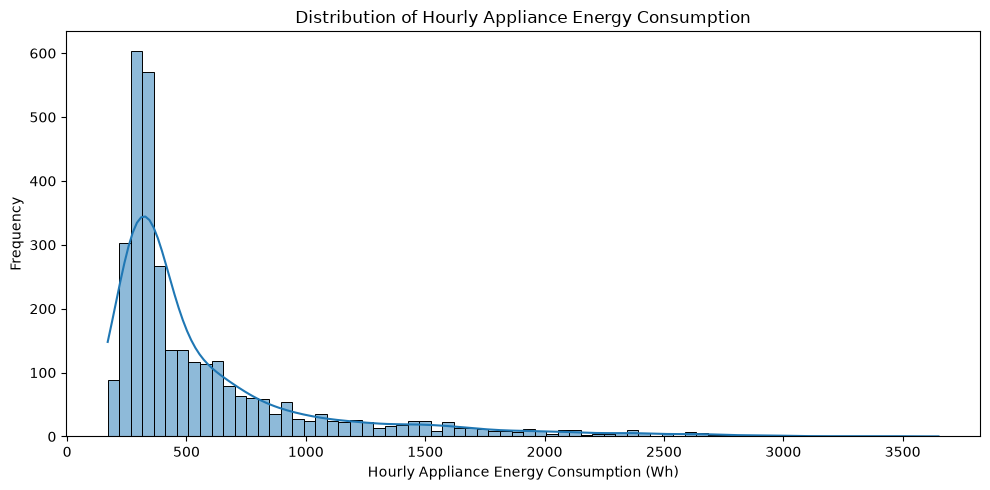

In [41]:
plt.figure(figsize=(10, 5))

sns.histplot(hourly_df["Appliances"], kde=True)

plt.title("Distribution of Hourly Appliance Energy Consumption")
plt.xlabel("Hourly Appliance Energy Consumption (Wh)")
plt.ylabel("Frequency")

plt.tight_layout()
plt.show()

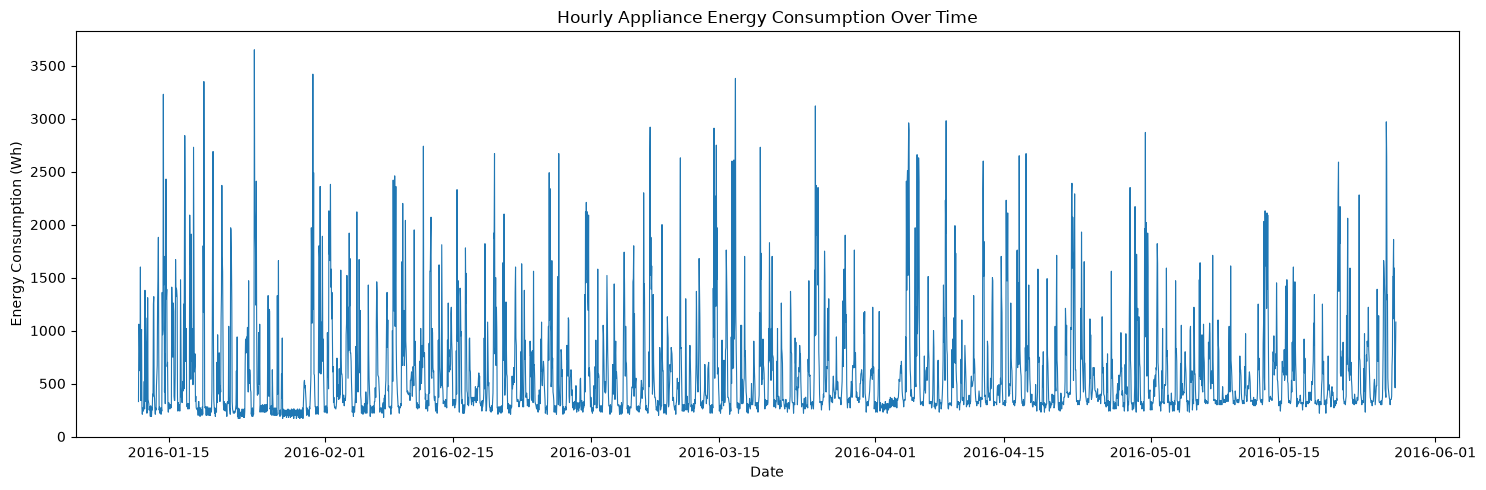

In [42]:
plt.figure(figsize=(15, 5))

plt.plot(
    hourly_df.index,
    hourly_df["Appliances"],
    linewidth=0.8
)

plt.title("Hourly Appliance Energy Consumption Over Time")
plt.xlabel("Date")
plt.ylabel("Energy Consumption (Wh)")

plt.tight_layout()
plt.show()

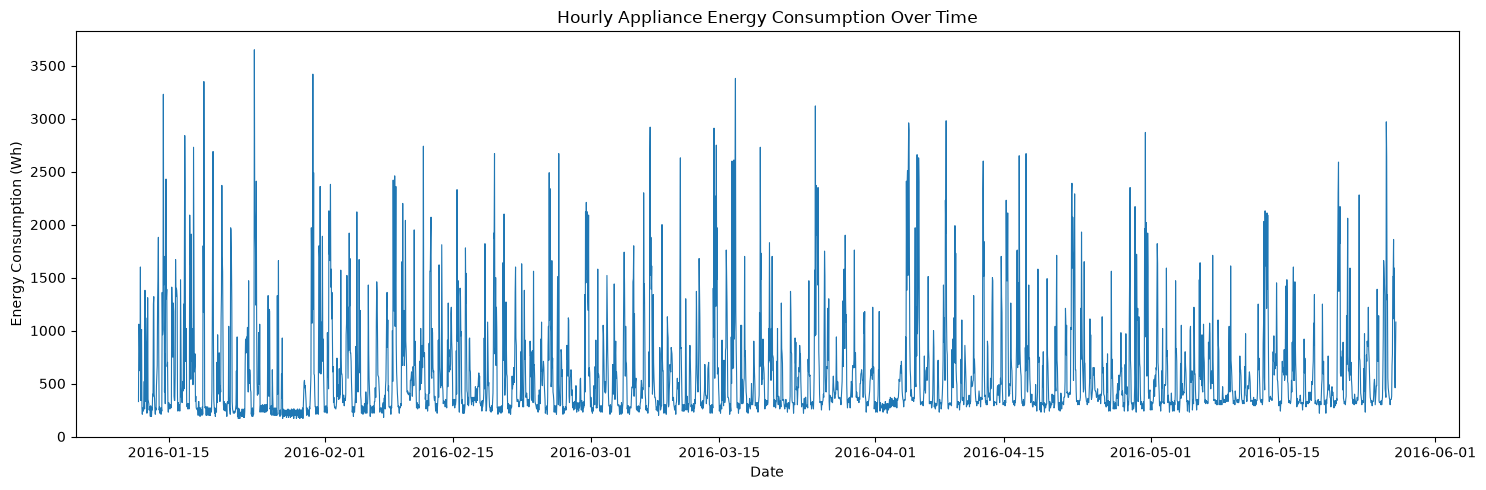

In [44]:
plt.figure(figsize=(15, 5))

plt.plot(
    hourly_df.index,
    hourly_df["Appliances"],
    linewidth=0.8
)

plt.title("Hourly Appliance Energy Consumption Over Time")
plt.xlabel("Date")
plt.ylabel("Energy Consumption (Wh)")

plt.tight_layout()
plt.show()

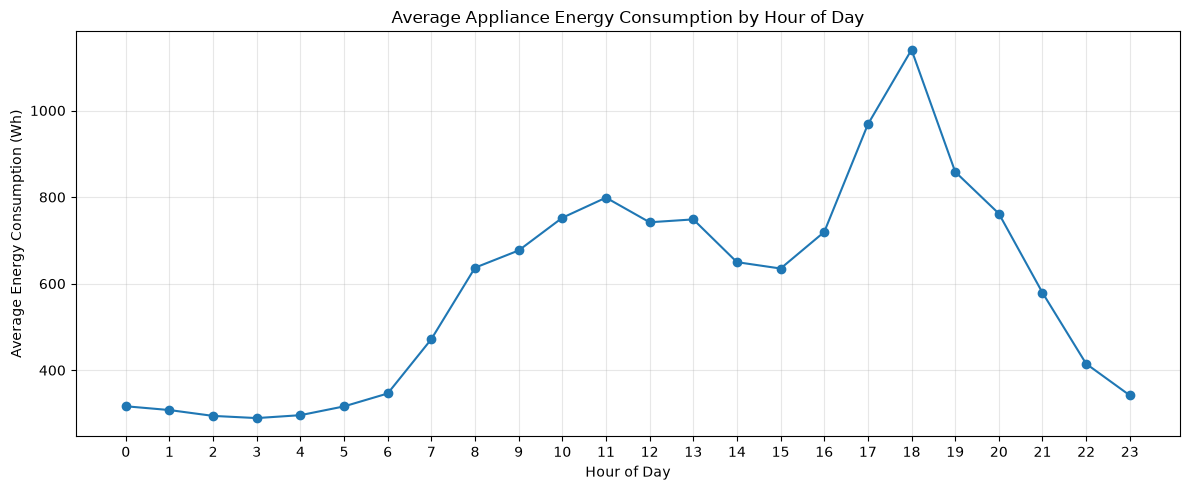

In [45]:
hourly_df["hour"] = hourly_df.index.hour

hourly_profile = hourly_df.groupby("hour")["Appliances"].mean()

plt.figure(figsize=(12, 5))

plt.plot(
    hourly_profile.index,
    hourly_profile.values,
    marker="o"
)

plt.title("Average Appliance Energy Consumption by Hour of Day")
plt.xlabel("Hour of Day")
plt.ylabel("Average Energy Consumption (Wh)")
plt.xticks(range(24))

plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

In [46]:
hourly_profile = hourly_df.groupby("hour")["Appliances"].mean()
hourly_profile

hour
0      316.715328
1      307.956204
2      294.452555
3      289.416058
4      296.131387
5      316.423358
6      346.277372
7      471.897810
8      636.861314
9      676.715328
10     752.262774
11     798.759124
12     741.824818
13     748.467153
14     649.708029
15     634.963504
16     719.416058
17     968.115942
18    1140.437956
19     858.394161
20     761.897810
21     578.978102
22     414.890511
23     341.897810
Name: Appliances, dtype: float64

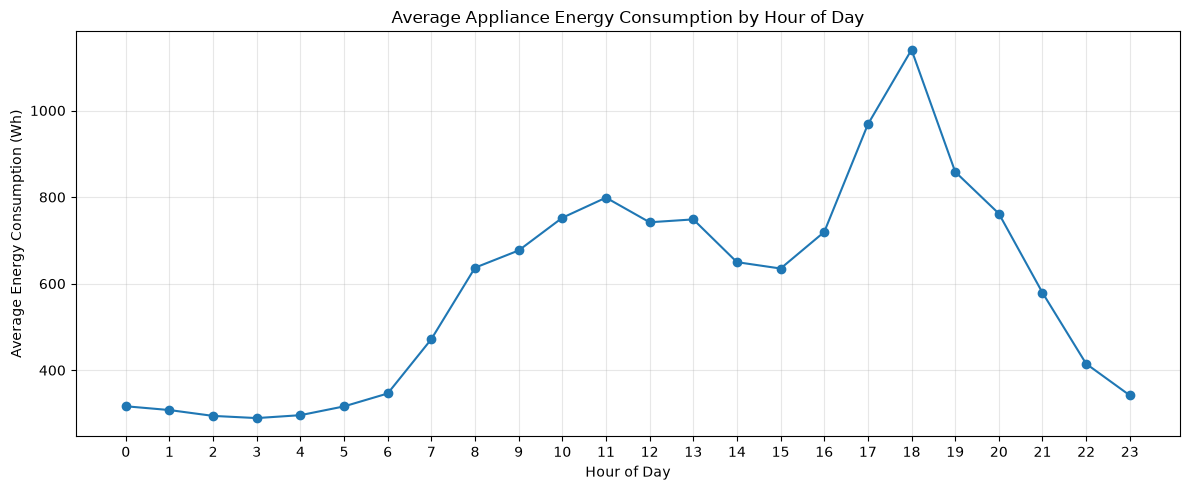

In [47]:
plt.figure(figsize=(12, 5))

plt.plot(
    hourly_profile.index,
    hourly_profile.values,
    marker="o"
)

plt.title("Average Appliance Energy Consumption by Hour of Day")
plt.xlabel("Hour of Day")
plt.ylabel("Average Energy Consumption (Wh)")
plt.xticks(range(24))

plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

In [ ]:
hourly_df["day_of_week"] = hourly_df.index.dayofweek
day_profile = hourly_df.groupby("day_of_week")["Appliances"].mean()
day_profile
# 0 = Monday and 6 = Sunday

day_of_week
0    668.704104
1    522.750000
2    539.583333
3    542.604167
4    627.046414
5    637.478070
6    569.495614
Name: Appliances, dtype: float64

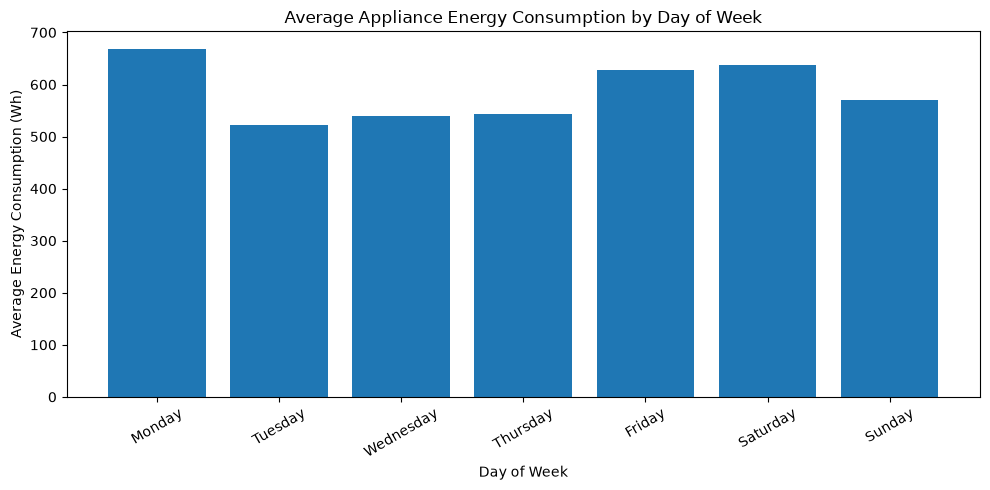

In [49]:
day_names = [
    "Monday",
    "Tuesday",
    "Wednesday",
    "Thursday",
    "Friday",
    "Saturday",
    "Sunday"
]

plt.figure(figsize=(10, 5))

plt.bar(day_names, day_profile.values)

plt.title("Average Appliance Energy Consumption by Day of Week")
plt.xlabel("Day of Week")
plt.ylabel("Average Energy Consumption (Wh)")

plt.xticks(rotation=30)
plt.tight_layout()
plt.show()

In [50]:
hourly_df["day_of_week"] = hourly_df.index.dayofweek

day_profile = hourly_df.groupby("day_of_week")["Appliances"].mean()

day_profile

day_of_week
0    668.704104
1    522.750000
2    539.583333
3    542.604167
4    627.046414
5    637.478070
6    569.495614
Name: Appliances, dtype: float64

In [ ]:
#previous 1,2,3,6 hours , same houer yesterday, 2 days, last week, last 28 days
lags = [1, 2, 3, 6, 24, 48, 168, 672]

lag_correlations = {}

for lag in lags:
    lag_correlations[f"lag_{lag}"] = (
        hourly_df["Appliances"]
        .corr(hourly_df["Appliances"].shift(lag))
    )

lag_correlations

{'lag_1': np.float64(0.581137030584338),
 'lag_2': np.float64(0.46281169527941507),
 'lag_3': np.float64(0.30149870915844096),
 'lag_6': np.float64(0.046316335857879205),
 'lag_24': np.float64(0.30636042115451295),
 'lag_48': np.float64(0.2251726061210446),
 'lag_168': np.float64(0.32945762837132386),
 'lag_672': np.float64(0.32215019617567586)}

In [54]:
rolling_windows = [3, 6, 24, 168, 672]

rolling_correlations = {}

for window in rolling_windows:
    rolling_mean = (
        hourly_df["Appliances"]
        .shift(1)
        .rolling(window)
        .mean()
    )

    rolling_correlations[f"rolling_mean_{window}"] = (
        hourly_df["Appliances"].corr(rolling_mean)
    )

rolling_correlations

{'rolling_mean_3': np.float64(0.5382791925987938),
 'rolling_mean_6': np.float64(0.3948493383237808),
 'rolling_mean_24': np.float64(0.1775314157983254),
 'rolling_mean_168': np.float64(-0.008510721899595354),
 'rolling_mean_672': np.float64(-0.017386804795102163)}

In [ ]:
target_correlations = (
    hourly_df
    .drop(columns=["hour", "day_of_week"], errors="ignore")
    .corr()["Appliances"]
    .drop("Appliances")
    .sort_values(key=abs, ascending=False)
)

target_correlations

lights         0.261375
RH_out        -0.193168
T2             0.152861
T6             0.148576
T_out          0.124456
RH_1           0.122825
RH_8          -0.119749
T3             0.114393
Windspeed      0.112784
RH_6          -0.105729
T1             0.071755
RH_7          -0.070372
RH_2          -0.069722
RH_9          -0.062923
RH_3           0.053097
T4             0.053026
T8             0.049153
Press_mm_hg   -0.044093
T7             0.032553
T5             0.022460
RH_4           0.021320
Tdewpoint      0.018333
T9             0.012318
Visibility    -0.002129
RH_5           0.001836
Name: Appliances, dtype: float64

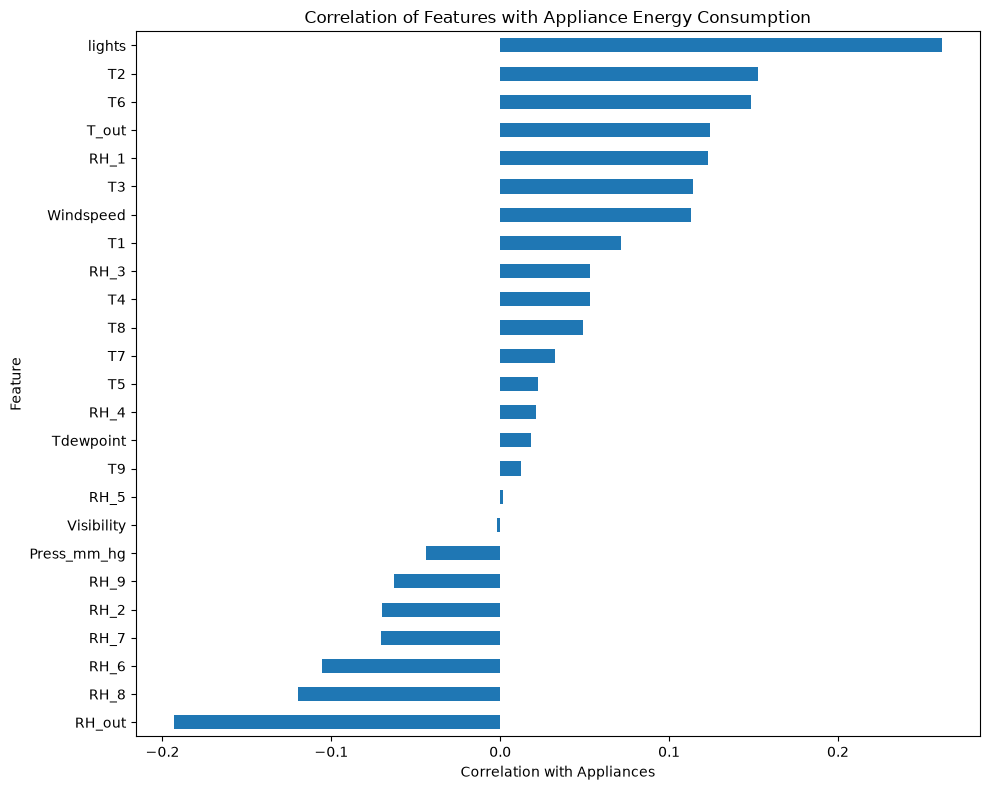

In [56]:
plt.figure(figsize=(10, 8))

target_correlations.sort_values().plot(kind="barh")

plt.title("Correlation of Features with Appliance Energy Consumption")
plt.xlabel("Correlation with Appliances")
plt.ylabel("Feature")

plt.tight_layout()
plt.show()

In [57]:
correlation_matrix = (
    hourly_df
    .drop(columns=["hour", "day_of_week"], errors="ignore")
    .corr()
)

correlation_matrix

,Appliances,lights,T1,RH_1,T2,RH_2,T3,RH_3,T4,RH_4,T5,RH_5,T6,RH_6,T7,RH_7,T8,RH_8,T9,RH_9,T_out,Press_mm_hg,RH_out,Windspeed,Visibility,Tdewpoint
Appliances,1.000000,0.261375,0.071755,0.122825,0.152861,-0.069722,0.114393,0.053097,0.053026,0.021320,0.022460,0.001836,0.148576,-0.105729,0.032553,-0.070372,0.049153,-0.119749,0.012318,-0.062923,0.124456,-0.044093,-0.193168,0.112784,-0.002129,0.018333
lights,0.261375,1.000000,-0.027489,0.126359,-0.006509,0.058955,-0.112385,0.151517,-0.009583,0.130862,-0.091037,0.166653,-0.090613,0.176906,-0.155587,0.040758,-0.082293,0.015977,-0.181274,-0.008557,-0.085907,-0.012267,0.079382,0.069844,0.023397,-0.042089
T1,0.071755,-0.027489,1.000000,0.164981,0.838209,-0.002619,0.893558,-0.029067,0.878485,0.097714,0.887791,-0.016054,0.655961,-0.616133,0.839335,0.135520,0.826036,-0.006164,0.845715,0.072202,0.683791,-0.150728,-0.346752,-0.088576,-0.079905,0.572441
RH_1,0.122825,0.126359,0.164981,1.000000,0.272343,0.802461,0.255406,0.853194,0.107212,0.889009,0.208698,0.321686,0.319564,0.247958,0.021551,0.809118,-0.030388,0.744074,0.116262,0.772761,0.344300,-0.296870,0.277982,0.208769,-0.023190,0.645638
T2,0.152861,-0.006509,0.838209,0.272343,1.000000,-0.164320,0.737064,0.121752,0.763893,0.231974,0.723576,0.030491,0.802338,-0.580947,0.665148,0.230152,0.579567,0.069343,0.677148,0.158475,0.793570,-0.133409,-0.506815,0.052214,-0.073464,0.584231
RH_2,-0.069722,0.058955,-0.002619,0.802461,-0.164320,1.000000,0.137871,0.681382,-0.047095,0.724216,0.111314,0.263490,-0.008192,0.390664,-0.051535,0.693289,-0.041195,0.682726,0.054753,0.679921,0.035120,-0.256686,0.587840,0.071100,-0.005797,0.501611
T3,0.114393,-0.112385,0.893558,0.255406,0.737064,0.137871,1.000000,-0.013043,0.854725,0.122793,0.891210,-0.069886,0.688437,-0.649131,0.848397,0.172909,0.796419,0.044516,0.902551,0.134919,0.700766,-0.190206,-0.282926,-0.101777,-0.107409,0.647367
RH_3,0.053097,0.151517,-0.029067,0.853194,0.121752,0.681382,-0.013043,1.000000,-0.141148,0.902294,-0.050337,0.392945,0.077323,0.517355,-0.251003,0.835704,-0.284370,0.832394,-0.195975,0.837485,0.118841,-0.234020,0.358924,0.266489,0.018512,0.416175
T4,0.053026,-0.009583,0.878485,0.107212,0.763893,-0.047095,0.854725,-0.141148,1.000000,-0.048983,0.875038,-0.080512,0.653847,-0.704875,0.879207,0.043636,0.797694,-0.095332,0.890994,-0.025466,0.664818,-0.075450,-0.390403,-0.187875,-0.110357,0.520764
RH_4,0.021320,0.130862,0.097714,0.889009,0.231974,0.724216,0.122793,0.902294,-0.048983,1.000000,0.092033,0.368719,0.259713,0.393348,-0.131559,0.895856,-0.167532,0.849341,-0.044783,0.859212,0.294020,-0.251120,0.338583,0.303354,0.002811,0.617723


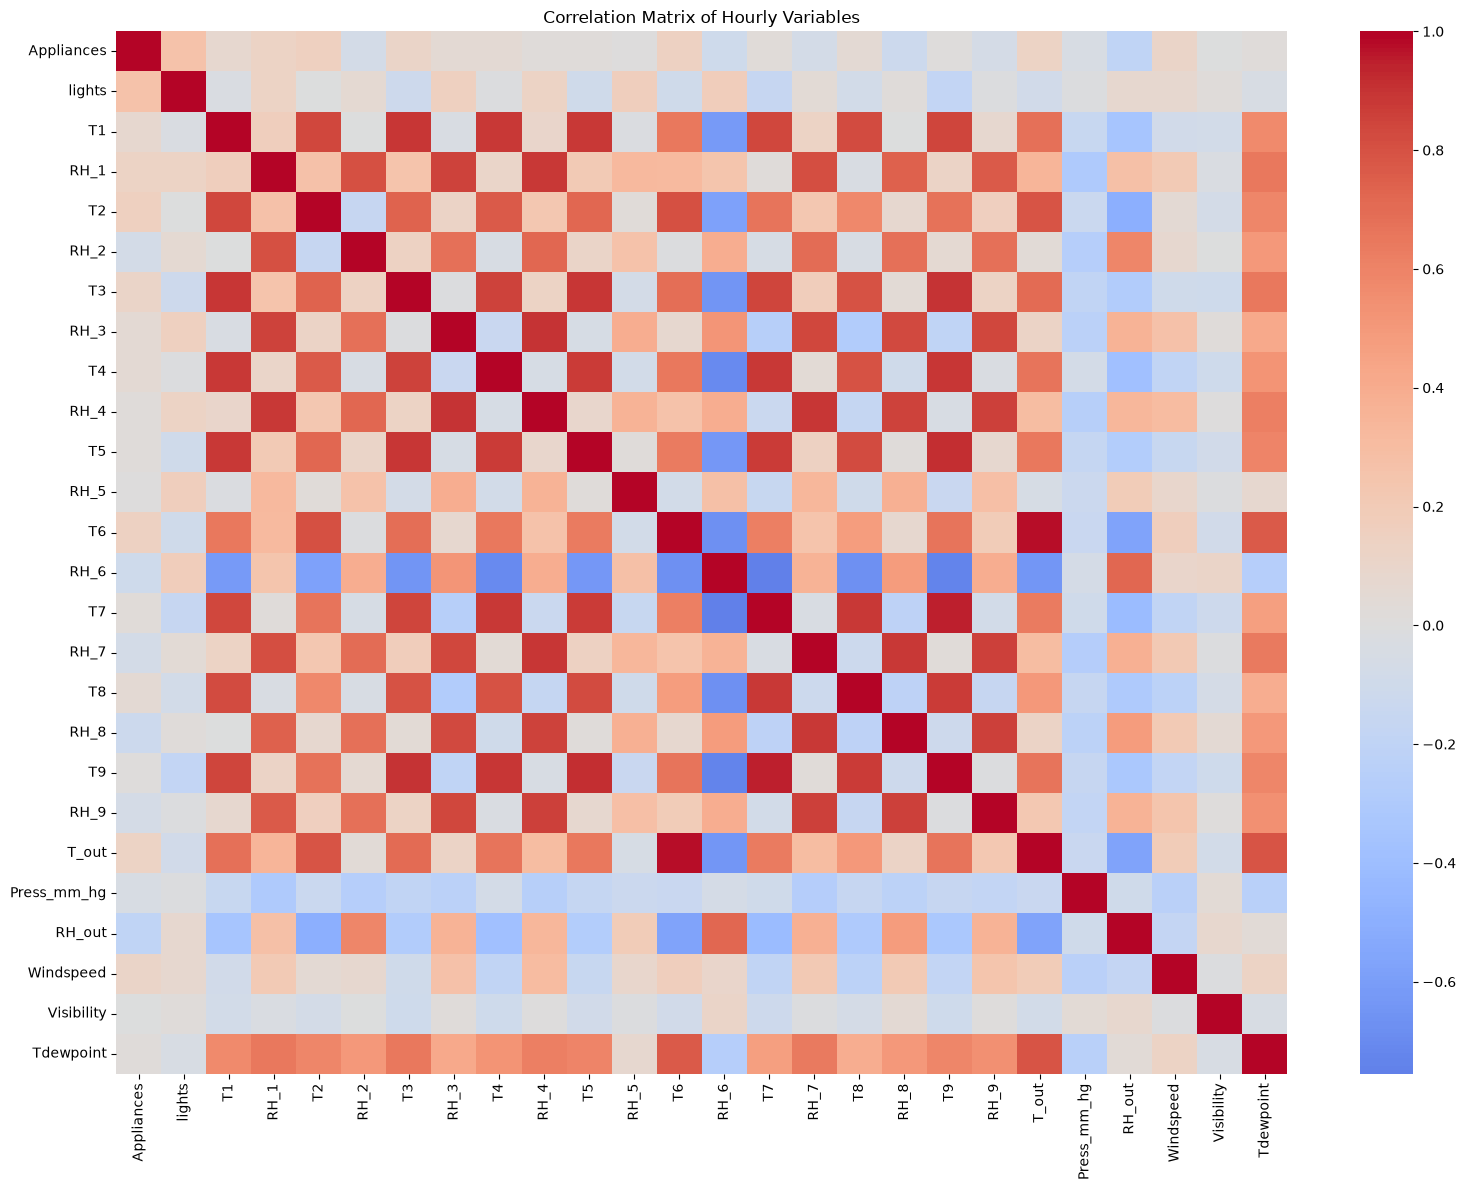

In [58]:
plt.figure(figsize=(16, 12))

sns.heatmap(
    correlation_matrix,
    cmap="coolwarm",
    center=0
)

plt.title("Correlation Matrix of Hourly Variables")

plt.tight_layout()
plt.show()

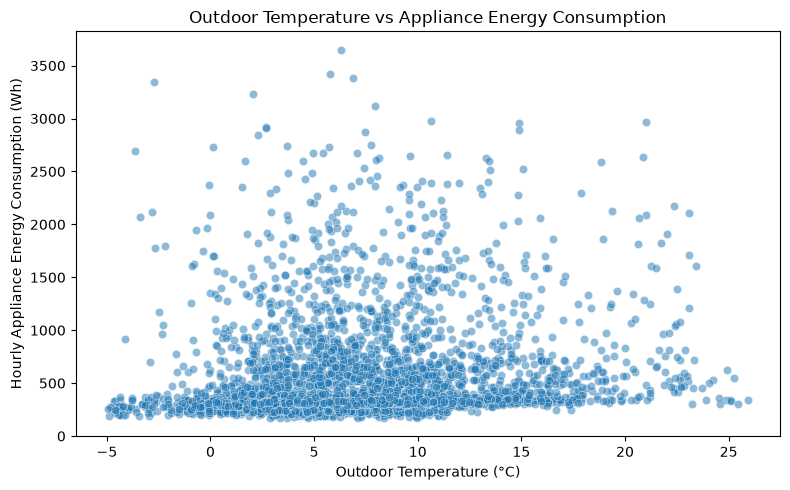

In [59]:
plt.figure(figsize=(8, 5))

sns.scatterplot(
    data=hourly_df,
    x="T_out",
    y="Appliances",
    alpha=0.5
)

plt.title("Outdoor Temperature vs Appliance Energy Consumption")
plt.xlabel("Outdoor Temperature (°C)")
plt.ylabel("Hourly Appliance Energy Consumption (Wh)")

plt.tight_layout()
plt.show()

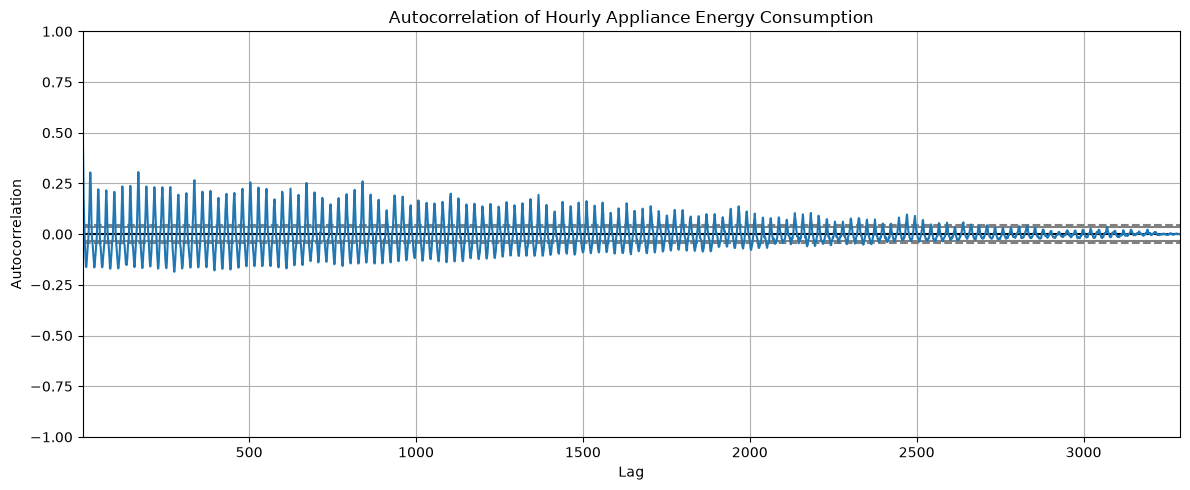

In [60]:
from pandas.plotting import autocorrelation_plot

plt.figure(figsize=(12, 5))

autocorrelation_plot(hourly_df["Appliances"])

plt.title("Autocorrelation of Hourly Appliance Energy Consumption")

plt.tight_layout()
plt.show()